In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

,Raw Errors,Sum,SSE,TotDist
0,"[2, -2]",0,8,2.828427
1,"[1, -3]",-2,10,3.162278
2,"[0, -4]",-4,16,4.000000
3,"[0, -2]",-2,4,2.000000
4,"[0, 0]",0,0,0.000000


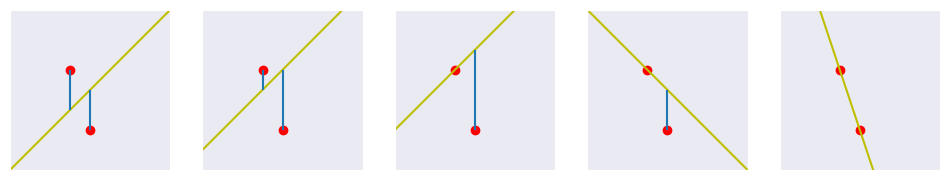

In [6]:
def axis_helper(ax, lims):
  ax.set_xlim(lims)
  ax.set_xticks([])
  ax.set_ylim(lims)
  ax.set_yticks([])
  ax.set_aspect('equal')


def process(D, model, ax):
  x, y = D[:, 0], D[:, 1]
  a, b = model
  axis_helper(ax, (0, 8))
  ax.plot(x, y, 'ro')
  # crtanje pravca
  helper_xs = np.array([0, 8])
  helper_line = a * helper_xs + b
  ax.plot(helper_xs, helper_line, color='y')
  # crtanje greške
  predictions = a * x + b
  ax.vlines(x, predictions, y)
  # izračun greške
  errors = y - predictions
  # vraćanje rezultata
  sse = np.dot(errors, errors)
  return (errors, errors.sum(), sse, np.sqrt(sse))


D = np.array([[3, 5],
[4, 2]])
# a b --> parametri pravca = ax + b
lines_mb = np.array([[ 1, 0],
[ 1, 1],
[ 1, 2],
[-1, 8],
[-3, 14]])
col_labels = ("Raw Errors", "Sum", "SSE", "TotDist")
results = []
# crtanje
fig, axes = plt.subplots(1, 5, figsize=(12, 6))
records = [process(D, mod, ax) for mod,ax in zip(lines_mb, axes.flat)]
df = pd.DataFrame.from_records(records, columns=col_labels)
display(df)
